### Set-up

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import textwrap

In [2]:
#set main paths
CUR_DIR = os.path.dirname(os.path.abspath(__name__))
print(CUR_DIR)
DATA_DIR = CUR_DIR+'/data/human_annotation/'
SCENARIO_DIR = CUR_DIR+'/scenarios/'

FILENAME = 'scenarios.json'

/Users/anna/Dropbox/2023_AOI/MoralLearning/CodeSets/graph_extract


### Define some function definitions for analysis

In [7]:
def open_scenario():
    """
    Opens a scenario file and returns its content.
    """
    scenario_path = os.path.join(SCENARIO_DIR, FILENAME)
    with open(scenario_path, 'r') as file:
        all_scenarios = json.load(file)
        
    # error handling for assumptions about json entries
    try:
        scenario_json = all_scenarios[SCENARIO]
    except:
        # print("Check scenario filename or scenario id")
        raise IndexError('Check scenario id exists in json file!')
        scenario_json = {}
    
    #make sure action id is in the scenario
    if str(CHOICE) not in scenario_json['options']:
        raise ValueError(f"Action ID {CHOICE} not found in scenario options.")


    # # display the scnenario text read in 
    # this_scenario_text = scenario_json["text"]    
    # print('Scenario Text: \n\n')
    # print(textwrap.fill(this_scenario_text, width = 100), '\n\n')


    return scenario_json

In [8]:
def compute_reliability(value_data):
    """
    Compute inter-rater reliability using correlation.
    
    Parameters:
    value_data (DataFrame): DataFrame containing annotator scores.
    
    Returns:
    float: Mean correlation between annotators.
    """
    # Select columns starting with 'p' for annotator scores
    annotator_columns = [col for col in value_data.columns if col.startswith('p')]
    annotator_data = value_data[annotator_columns].values
    
    # Compute all pairwise correlations
    correlations = np.corrcoef(annotator_data, rowvar=False)
    
    # Take the upper triangle of the correlation matrix
    upper_triangle_indices = np.triu_indices_from(correlations, k=1)
    
    # Extract the upper triangle values
    upper_triangle_values = correlations[upper_triangle_indices]
    
    # Take the mean of the upper triangle values
    mean_correlation = np.mean(upper_triangle_values)


    print(f"Mean correlation between raters: {mean_correlation:.2f}")
    
    return mean_correlation


In [9]:
def calc_binary_agreement(rater_data):
    """
    Calculate the binary agreement between raters.
    
    Parameters:
    links_data (DataFrame): DataFrame containing rater data.
    
    Returns:
    float: Mean binary agreement across all rows.
    """

    agreement_data = []

    for idx,this_row in rater_data.iterrows():

        n = len(this_row)
        agreement_0 = sum(this_row==0)
        agreement_1 = sum(this_row==1) 
        agreement = abs(agreement_0-agreement_1) / n
        agreement_data.append(agreement)
        # print(f"Row {idx} has {agreement_0} 0s and {agreement_1} 1s out of {n} total ratings.")
        # print(f"Agreement for row {idx}: {agreement:.2f}")

    mean_agreement = np.mean(agreement_data)
    print(f"Mean binary agreement across all raters: {mean_agreement:.3f}")
    return(mean_agreement)

### Select Scenario to view 

In [17]:
#this scenario and choice will be displayed in the plots
SCENARIO = 0
CHOICE = 2

In [10]:
#set of scenarios to loop through and corresponding # of action choices 
scenarios = [0, 1, 2, 8]
num_choices = [3,3,2,2]

### Value Scores

##### evaluate all scenarios in list

In [18]:
#read in each scenario and output aggregated results
for scenario, num_choice in zip(scenarios, num_choices):
    for choice in range(1,num_choice):
        filename_value_scores = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_value_scores.csv"
        value_data = pd.read_csv(filename_value_scores, usecols=lambda column: column != 'Unnamed: 0')
        print(f"Scenario: {scenario}, Choice: {choice}")

        #report overall correlation between annotator_scores and mean
        correlation = np.corrcoef(value_data['annotator_scores'], value_data['mean'])[0, 1]
        print(f"Correlation between annotator scores and mean scores: {correlation:.2f}")
        compute_reliability(value_data)
        #compute the mean absolute distance by taking the mean in the value_data
        print(f"Mean absolute distance from annotator scores: {np.mean(value_data['mean_abs_dist']):.2f}")

Scenario: 0, Choice: 1
Correlation between annotator scores and mean scores: 0.70
Mean correlation between raters: 0.26
Mean absolute distance from annotator scores: 25.81
Scenario: 0, Choice: 2
Correlation between annotator scores and mean scores: 0.51
Mean correlation between raters: 0.05
Mean absolute distance from annotator scores: 25.05
Scenario: 1, Choice: 1
Correlation between annotator scores and mean scores: 0.80
Mean correlation between raters: 0.21
Mean absolute distance from annotator scores: 25.80
Scenario: 1, Choice: 2
Correlation between annotator scores and mean scores: -0.31
Mean correlation between raters: nan
Mean absolute distance from annotator scores: 30.27
Scenario: 2, Choice: 1
Correlation between annotator scores and mean scores: 0.76
Mean correlation between raters: 0.44
Mean absolute distance from annotator scores: 25.42
Scenario: 8, Choice: 1
Correlation between annotator scores and mean scores: 0.16
Mean correlation between raters: 0.50
Mean absolute distan

/Users/anna/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/anna/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Outcome Likelihood Ratings

In [19]:

results = []
for scenario, num_choice in zip(scenarios, num_choices):
    for choice in range(1,num_choice):
        filename_outcome_scores = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_outcomes.csv"
        this_outcome_data = pd.read_csv(filename_outcome_scores, usecols=lambda column: column != 'Unnamed: 0')
        print(f"Mean ratings (100 is correct): {np.mean(this_outcome_data['mean']):.2f}")
        results.append({
            "scenario": scenario,
            "choice": choice,
            "mean": np.mean(this_outcome_data['mean']),
            "sem": stats.sem(this_outcome_data['mean']),
        })
        if (scenario == SCENARIO and choice == CHOICE):
            outcome_data = this_outcome_data

Mean ratings (100 is correct): 82.21
Mean ratings (100 is correct): 79.51
Mean ratings (100 is correct): 77.96
Mean ratings (100 is correct): 81.91
Mean ratings (100 is correct): 84.60
Mean ratings (100 is correct): 90.33


In [20]:
#get the mean of the means
mean_of_means = np.mean([result['mean'] for result in results])
print(f"Mean across scenarios: {mean_of_means:.2f}")


Mean across scenarios: 82.76


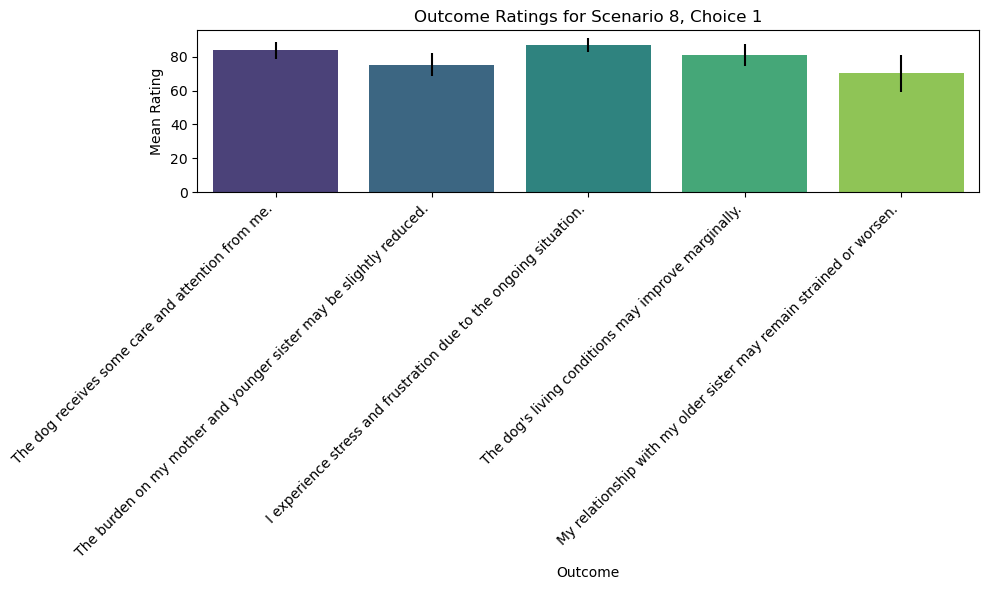

In [21]:
#select only mean and se_mean columns
outcome_data_simple = outcome_data[['outcome','mean', 'se_mean']]

#plot the outcome data using outcome as the x-axis and mean as the y-axis, with se_mean as the error bars
#add a legend for the x axis labels along the right side of the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='outcome', y='mean', data=outcome_data_simple, yerr=outcome_data_simple['se_mean'], capsize=0.1, palette='viridis')
plt.xlabel('Outcome')
plt.ylabel('Mean Rating')
plt.xticks(rotation=45, ha='right')
plt.title(f'Outcome Ratings for Scenario {scenario}, Choice {choice}')
plt.tight_layout()
plt.show()

### Outcome Utilities

In [23]:
#read in each scenario and output aggregated results
results = []
all_util_data = np.array([])
for scenario, num_choice in zip(scenarios, num_choices):
    for choice in range(1,num_choice+1):
        filename_util_scores = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_outcome_utilities.csv"
        this_util_data = pd.read_csv(filename_util_scores, usecols=lambda column: column != 'Unnamed: 0')    
        print(f"Scenario: {scenario}, Choice: {choice}")
        correlation = np.corrcoef(this_util_data['annot_scores'], this_util_data['subj_means'])[0, 1]
        print(f"Correlation between annotator scores and mean scores: {correlation:.2f}")
        mean_agree = compute_reliability(this_util_data)
        #add to results
        results.append({
            "scenario": scenario,
            "choice": choice,
            "correlation": correlation,
            "mean_agree": mean_agree,
            "util_data": this_util_data
        })
   

Scenario: 0, Choice: 1
Correlation between annotator scores and mean scores: 0.68
Mean correlation between raters: 0.27
Scenario: 0, Choice: 2
Correlation between annotator scores and mean scores: 0.68
Mean correlation between raters: 0.25
Scenario: 0, Choice: 3
Correlation between annotator scores and mean scores: 0.83
Mean correlation between raters: 0.60
Scenario: 1, Choice: 1
Correlation between annotator scores and mean scores: 0.78
Mean correlation between raters: 0.43
Scenario: 1, Choice: 2
Correlation between annotator scores and mean scores: 0.94
Mean correlation between raters: 0.43
Scenario: 1, Choice: 3
Correlation between annotator scores and mean scores: 0.92
Mean correlation between raters: 0.67
Scenario: 2, Choice: 1
Correlation between annotator scores and mean scores: 0.73
Mean correlation between raters: 0.74
Scenario: 2, Choice: 2
Correlation between annotator scores and mean scores: 0.88
Mean correlation between raters: 0.72
Scenario: 8, Choice: 1
Correlation betwe

In [29]:
#get the mean correlation from results
mean_corr = np.mean([r['correlation'] for r in results])
#print result
print(f"Mean correlation between annotator scores and mean scores: {mean_corr:.2f}")

Mean correlation between annotator scores and mean scores: 0.74


#### plotting for selected scenario

In [34]:
#this scenario and choice will be displayed in the plots
SCENARIO = 0
CHOICE = 2
#select entity
ENTITY  = 1
#read in the scenario
scenario_json = open_scenario()
ACTION = scenario_json['options'][str(CHOICE)]
print('Selected action: I '+ ACTION)

Selected action: I continue taking care of it


In [35]:
#pull out the selected scenario and choice data from results
for elem in results:
    if(elem['scenario']==SCENARIO and elem['choice']==CHOICE):
        util_data = elem['util_data']
        

In [36]:
#turn util_data into long format with annot_scores and subj_means combined into a columne called "rating" and their respective columns as "type"; include columns 'entity' and 'subj_se'
util_data_long = pd.melt(util_data, id_vars=['outcome', 'entity', 'subj_se'], value_vars=['annot_scores', 'subj_means'], 
                         var_name='type', value_name='rating')

#where type is annot_scores, set subj_se to 0
util_data_long.loc[util_data_long['type'] == 'annot_scores', 'subj_se'] = 0

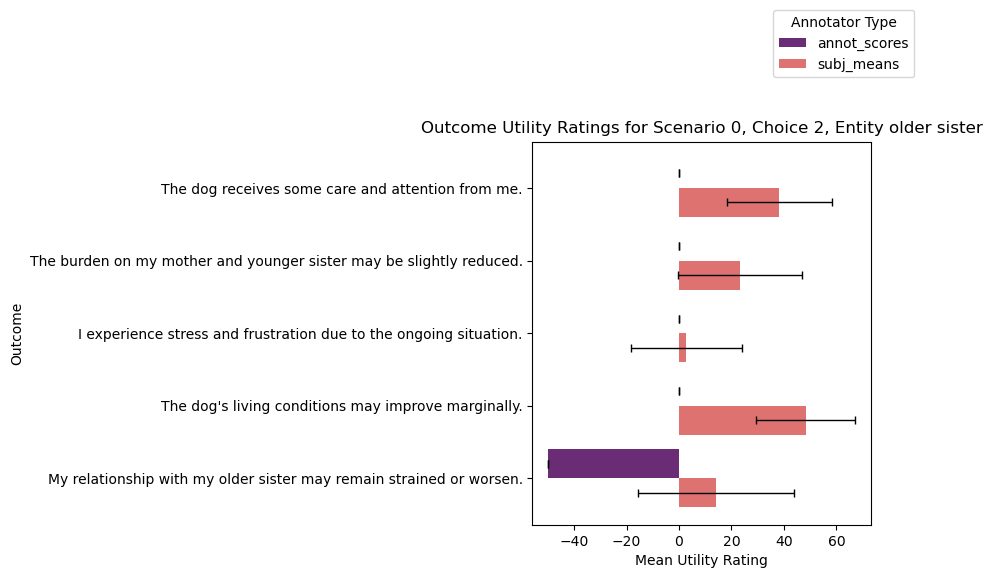

In [37]:
#plot based on settings above
entity_names = util_data_long['entity'].unique()
plot_data = util_data_long[util_data_long['entity'] == entity_names[ENTITY]]
#create a horizontal bar plot of the outcome ratings with separate bars for each entity, and using rating as the x-axis and outcome as the y-axis, with subj_se as the error bars

plt.figure(figsize=(10, 6))

ax = sns.barplot(y='outcome', x='rating', hue='type', data=plot_data, capsize=0.1, palette='magma')

# Add error bars manually
for i, (bar, (_, row)) in enumerate(zip(ax.patches, plot_data.iterrows())):
    # Get the bar position
    y = bar.get_y() + bar.get_height() / 2
    x = bar.get_width()
    err = row['subj_se']
    ax.errorbar(x, y, xerr=err, fmt='none', c='black', capsize=3, linewidth=1)

plt.ylabel('Outcome')
plt.xlabel('Mean Utility Rating')
plt.yticks(rotation=0)
#put the legend outside the chart area
plt.legend(title='Annotator Type', bbox_to_anchor=(1.15, 1.15), loc='lower right')
plt.title(f'Outcome Utility Ratings for Scenario {SCENARIO}, Choice {CHOICE}, Entity {entity_names[ENTITY]}')
plt.tight_layout()
plt.show()

### Outcome Links

In [298]:
results_links = [] 
for scenario, num_choice in zip(scenarios, num_choices):
    for choice in range(1,num_choice+1):
        filename_links = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_outcome_links.csv"
        links_data = pd.read_csv(filename_links, usecols=lambda column: column != 'Unnamed: 0')
        #compute mean agreement between raters
        #select columns starting with 'p' for rater data
        rater_data = links_data.filter(regex='^p', axis=1)
        mean_agree = calc_binary_agreement(rater_data)


        mean_agreement_annot = np.mean(links_data['agreement_percentage'])
        print(f"Mean agreement with annotator: {mean_agreement_annot:.2f}")

        results_links.append({
            "scenario": scenario,
            "choice": choice,
            "rater_agreement": mean_agree,
            "annot_agreement": mean_agreement_annot,
            "links_data": links_data
        })



Mean binary agreement across all raters: 0.317
Mean agreement with annotator: 0.56
Mean binary agreement across all raters: 0.543
Mean agreement with annotator: 0.52
Mean binary agreement across all raters: 0.417
Mean agreement with annotator: 0.64
Mean binary agreement across all raters: 0.286
Mean agreement with annotator: 0.58
Mean binary agreement across all raters: 0.519
Mean agreement with annotator: 0.76
Mean binary agreement across all raters: 0.415
Mean agreement with annotator: 0.56
Mean binary agreement across all raters: 0.440
Mean agreement with annotator: 0.48
Mean binary agreement across all raters: 0.319
Mean agreement with annotator: 0.50
Mean binary agreement across all raters: 0.437
Mean agreement with annotator: 0.71
Mean binary agreement across all raters: 0.383
Mean agreement with annotator: 0.54


#### plot selected scenario

In [322]:
#this scenario and choice will be displayed in the plots
SCENARIO = 0
CHOICE = 1
LINK_TYPE = 'Intend' #or "Intent" or "Expect:

In [323]:
#read in the scenario
scenario_json = open_scenario()
ACTION = scenario_json['options'][str(CHOICE)]

In [324]:
#pull out the selected scenario and choice data from results
for elem in results_links:
    if(elem['scenario']==SCENARIO and elem['choice']==CHOICE):
        links_data = elem['links_data']
        #select one link type to plot

if LINK_TYPE=='Cause':
    links_data_type = links_data[links_data['link_type'] == 'Cause']


if LINK_TYPE=='Expect':
    links_data_type = links_data[links_data['link_type'] == 'Expect']


if LINK_TYPE=='Intend':
    links_data_type = links_data[links_data['link_type'] == 'Intend']


links_data_type_simple = links_data_type[['outcome_name', 'subj_mean', 'subj_se', 'annot_links']]
#convert links_data_cause to long format with annot_links and subj_mean combined into a column called "rating" and their respective columns as "type"; include columns 'outcome_name' and 'subj_se'
links_data_type_long = pd.melt(links_data_type_simple, id_vars=['outcome_name', 'subj_se'],
                                    value_vars=['annot_links', 'subj_mean'],
                                    var_name='type', value_name='rating')
#where type is annot_links, set subj_se to 0
links_data_type_long.loc[links_data_type_long['type'] == 'annot_links', 'subj_se'] = 0

refuse to take care of the dog unless my sister steps up and takes responsibility.


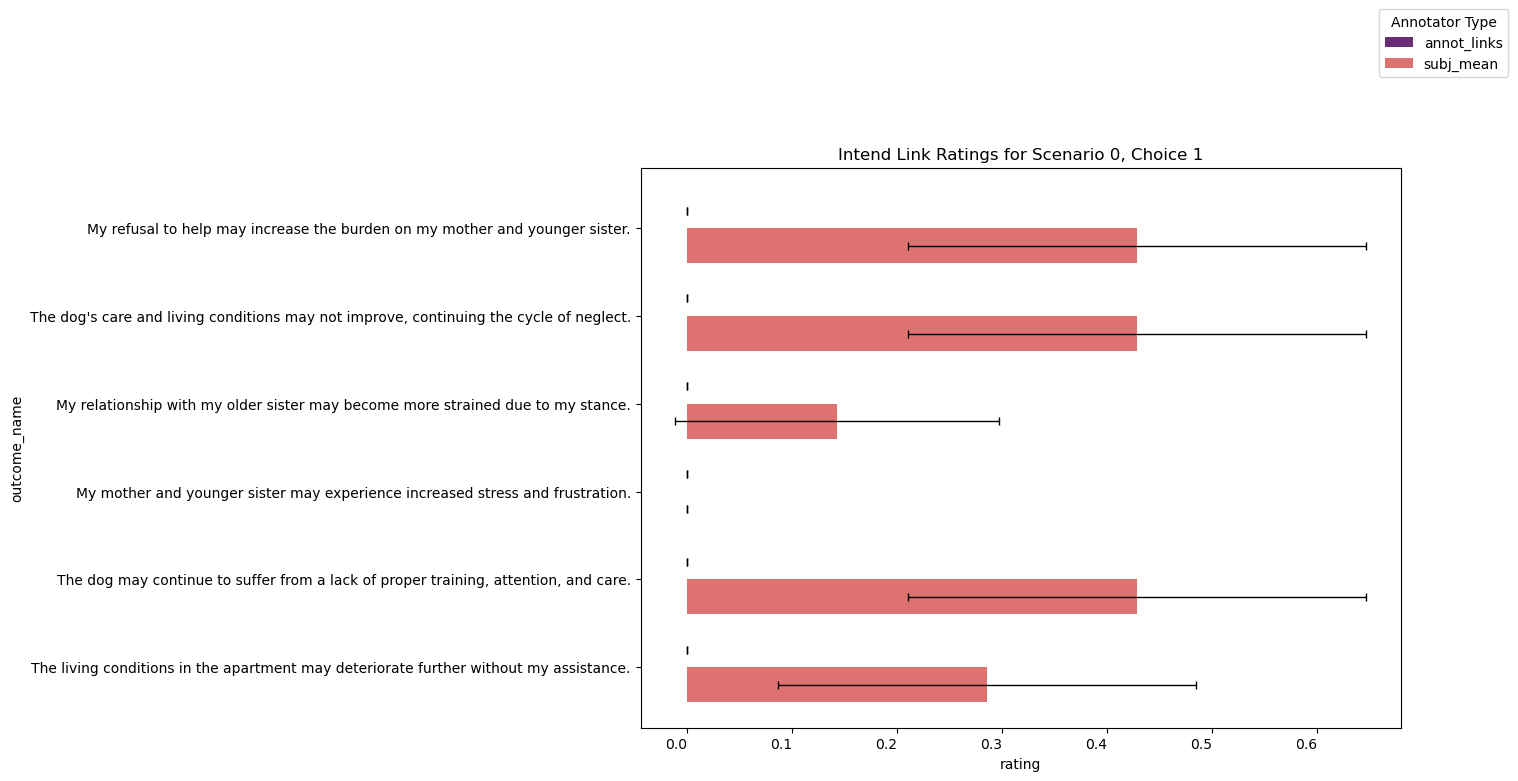

In [325]:
#select only the link types "cause" and make a plot showing subj_mean in a bar plot with error bars based on subj_se
#add a bar next to it showing the value of annot_links

plt.figure(figsize=(16, 8))
ax=sns.barplot(y='outcome_name', x='rating', hue='type', data=links_data_type_long, errorbar=None, capsize=2, palette='magma')


# Add error bars manually
for i, (bar, (_, row)) in enumerate(zip(ax.patches, links_data_type_long.iterrows())):
    # Get the bar position
    y = bar.get_y() + bar.get_height() / 2
    x = bar.get_width()
    err = row['subj_se']
    ax.errorbar(x, y, xerr=err, fmt='none', c='black', capsize=3, linewidth=1)

plt.xticks(rotation=0, ha='right')

plt.legend(title='Annotator Type', bbox_to_anchor=(1.15, 1.15), loc='lower right')
plt.title(f'{LINK_TYPE} Link Ratings for Scenario {SCENARIO}, Choice {CHOICE}')
plt.tight_layout()
print(ACTION)
plt.show()